# 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline
plt.style.use('ggplot') 

# 2. Load Dataset
Chúng ta tải dữ liệu huấn luyện đã qua tiền xử lý từ tệp `data/processed/train_no_outlier_IQR.csv.` Dữ liệu này đã được làm sạch và lọc bỏ các giá trị ngoại lệ (outliers) bằng phương pháp Khoảng biến thiên giữa các tứ phân vị (IQR).

In [23]:
train_clean = pd.read_csv('../data/processed/train_no_outlier_IQR.csv')
print(f"Dataset shape: {train_clean.shape}")
train_clean.head()

Dataset shape: (1288, 202)


,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,3,2,7,5,2003,2003,196.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,3,2,6,8,1976,1976,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,2,2,7,5,2001,2002,162.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,2,2,7,5,1915,1970,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,2,2,8,5,2000,2000,350.0,...,False,False,False,False,True,False,False,False,True,False


In [24]:
# Kiểm tra xem có cột nào còn NaN không
print(train_clean.isnull().sum().sort_values(ascending=False).head(5))

# Nếu còn NaN, hãy điền bằng giá trị trung bình (Mean)
train_clean = train_clean.fillna(train_clean.mean(numeric_only=True))

MSSubClass     0
LotFrontage    0
LotArea        0
LotShape       0
LandSlope      0
dtype: int64


# 3. Feature Selection & Data Splitting
Sau khi phân tích ma trận tương quan (Heatmap), chúng ta tiến hành tinh lọc các biến có ảnh hưởng mạnh nhất đến giá nhà để tối ưu hóa hiệu suất mô hình.

In [25]:
train_clean['BsmtQual'].dtypes

dtype('int64')

In [26]:
# 1. Chọn danh sách Features dựa trên Heatmap (Correlation > 0.6)
advanced_features = [
    'OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 
    'KitchenQual', 'GarageCars', 'Total_Bathrooms', 'YearBuilt', 'BsmtQual'
]

X = train_clean[advanced_features]
y = train_clean['SalePrice']

# 2. Chia dữ liệu Train/Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Selected the top {len(advanced_features)} most significant features.")
print(f"Training set shape: {X_train.shape}")

Selected the top 9 most significant features.
Training set shape: (1030, 9)


# 4. Advanced Modeling: Random Forest Regressor
Thay vì chỉ sử dụng một biến duy nhất, chúng ta áp dụng thuật toán Random Forest — một mô hình mạnh mẽ dựa trên sự kết hợp của nhiều cây quyết định (Decision Trees) để nắm bắt các mối quan hệ phi tuyến tính phức tạp trong dữ liệu.

In [27]:
# 1. Khởi tạo mô hình Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Huấn luyện
rf_model.fit(X_train, y_train)

# 3. Dự đoán trên tập Validation (dạng Log)
y_pred_log = rf_model.predict(X_val)

# 4. Đưa về đơn vị Đô-la thực tế để so sánh với Baseline
y_val_usd = np.exp(y_val)
y_pred_usd = np.exp(y_pred_log)

# 5. Tính RMSE mới
rmse_advanced = np.sqrt(mean_squared_error(y_val_usd, y_pred_usd))

print(f"--- RESULT OF ADVANCED MODEL ---")
print(f"RMSE (Actual Price): ${rmse_advanced:,.2f}")
print(f"Improvement over Baseline ($53,161): ${53161.01 - rmse_advanced:,.2f}")

--- RESULT OF ADVANCED MODEL ---
RMSE (Actual Price): $23,139.64
Improvement over Baseline ($53,161): $30,021.37


# 5. Feature Importance Analysis
Sau khi huấn luyện mô hình Random Forest, chúng ta sử dụng thuộc tính `feature_importances` để xác định xem những yếu tố nào có tác động mạnh nhất đến việc dự báo giá nhà.

In [28]:
# 1. Lấy độ quan trọng từ mô hình
importances = rf_model.feature_importances_
feature_names = advanced_features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

/var/folders/_v/244zbvxn47b36lb5y7wq4kmm0000gn/T/ipykernel_72641/3365480531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


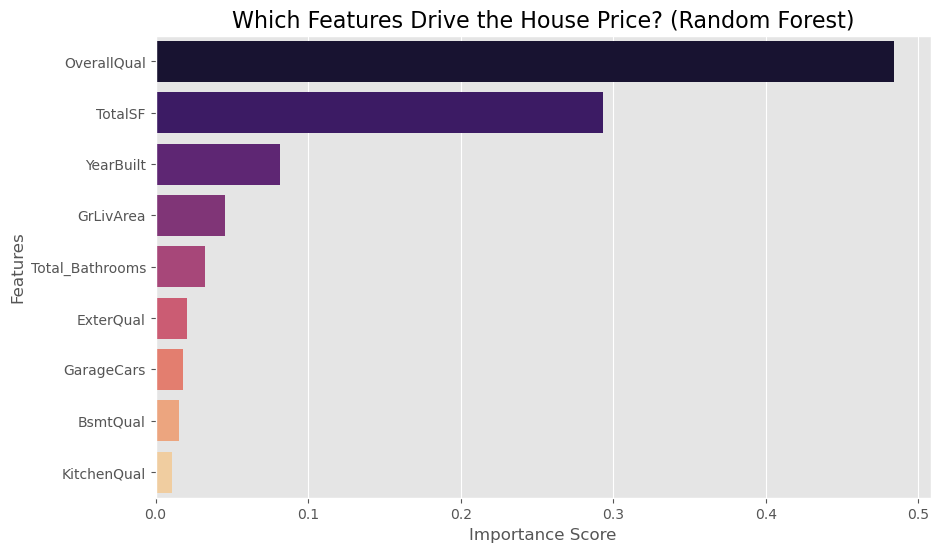

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Which Features Drive the House Price? (Random Forest)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 6. Model Evaluation: Actual vs. Predicted Price
Để có cái nhìn trực quan nhất về hiệu suất của mô hình nâng cao, chúng ta sử dụng `Scatter Plot` (biểu đồ phân tán) để so sánh giá trị dự báo từ mô hình với giá trị thực tế trong tập Validation.

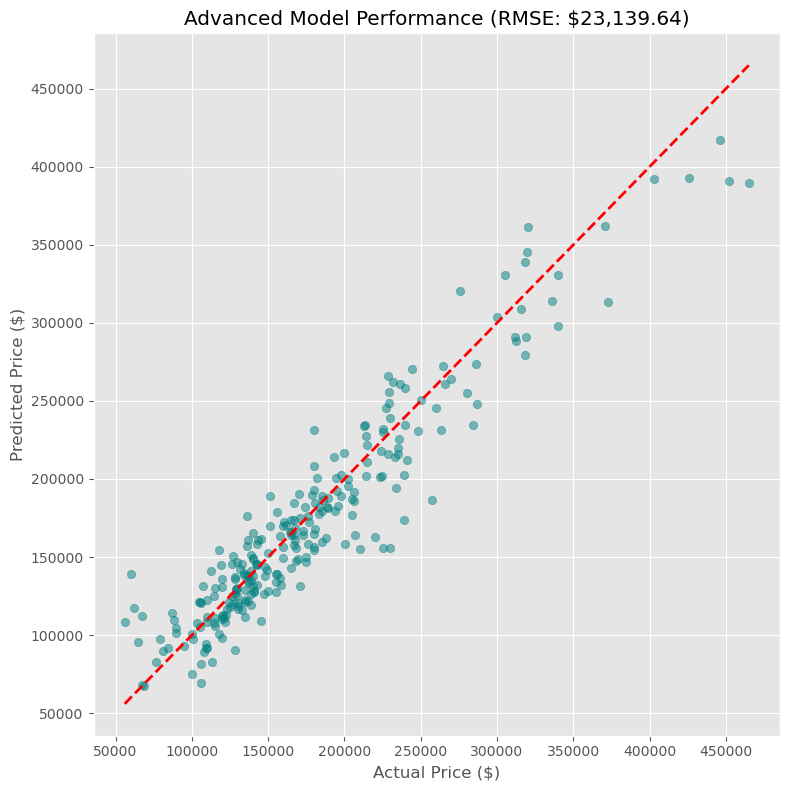

In [30]:
plt.figure(figsize=(8, 8))
plt.scatter(y_val_usd, y_pred_usd, alpha=0.5, color='teal')
plt.plot([y_val_usd.min(), y_val_usd.max()], [y_val_usd.min(), y_val_usd.max()], 'r--', lw=2)

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Advanced Model Performance (RMSE: ${rmse_advanced:,.2f})')
plt.tight_layout()
plt.show()

# 7. Final Inference & Submission Generation

In [31]:
test_clean = pd.read_csv('../data/processed/test.csv') 
print(test_clean.columns)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandSlope',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=188)


In [32]:
# 1. Nạp file Id gốc (để đảm bảo Id chính xác 100%)
raw_test = pd.read_csv('../data/raw/test.csv')
test_ids = raw_test['Id']

# 2. Nạp file đã xử lý
test_processed = pd.read_csv('../data/processed/test.csv')

# 3. Chọn Features và Dự đoán
X_test = test_processed[advanced_features]
test_preds_log = rf_model.predict(X_test)

# 4. Đưa về giá USD thực tế
test_preds_usd = np.exp(test_preds_log)

# 5. Tạo DataFrame Submission 
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_preds_usd
})

# 6. Xuất file final
submission.to_csv('../data/processed/final_submission_RF.csv', index=False)

submission.shape
submission.head()

,Id,SalePrice
0,1461,115447.791479
1,1462,156279.683969
2,1463,161921.528052
3,1464,183319.312317
4,1465,196930.660772
